# 04. Data Visualization & Trend Analysis

This notebook analyzes the **Unified Supply & Demand Data** with a focus on trends over time broken down by data source:
1.  **Job (Demand)**: What companies are asking for.
2.  **StackOverflow (Supply/Interest)**: What developers are asking about.
3.  **GitHub (Supply/Usage)**: What developers are building.
4.  **All (Combined)**: Overall market landscape.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Data Loading & Preprocessing

In [2]:
# Load Data
file_path = 'data/outputs/merged_supply_data.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Loaded Unified Data: {df.shape}")
except FileNotFoundError:
    print(f"Error: {file_path} not found.")
    df = pd.DataFrame()

# Preprocess Languages
def clean_language(lang_str):
    if pd.isna(lang_str):
        return []
    return [x.strip().lower() for x in str(lang_str).split(',')]

df_lang = df.copy()
df_lang['language_list'] = df_lang['language'].apply(clean_language)
df_exploded = df_lang.explode('language_list')
df_exploded.rename(columns={'language_list': 'clean_language'}, inplace=True)
df_exploded = df_exploded[df_exploded['clean_language'] != '']

# Preprocess Dates (Ensure Year is valid)
df_exploded['event_date'] = pd.to_numeric(df_exploded['event_date'], errors='coerce')
df_exploded = df_exploded.dropna(subset=['event_date'])
df_exploded['event_date'] = df_exploded['event_date'].astype(int)

print("Top 10 Languages:")
print(df_exploded['clean_language'].value_counts().head(10))

Loaded Unified Data: (26268, 4)
Top 10 Languages:
clean_language
python        4184
java          2193
c             2112
javascript    1976
c#            1713
r             1635
c++           1529
go            1280
typescript    1243
rust          1219
Name: count, dtype: int64


## Helper Function for Plotting

In [3]:
def plot_trend(data, source_name, top_n=5):
    """
    Plots smoothed trend and relative popularity for a given dataset segment.
    """
    if data.empty:
        print(f"No data available for {source_name}")
        return

    # Identify top languages for this specific source
    top_langs = data['clean_language'].value_counts().head(top_n).index.tolist()
    print(f"Top {top_n} languages in {source_name}: {top_langs}")

    # Filter data
    trend_df = data[data['clean_language'].isin(top_langs)]
    
    # Basic Count
    trend_counts = trend_df.groupby(['event_date', 'clean_language']).size().reset_index(name='count')

    # Smoothing (Rolling Average)
    pivot_df = trend_counts.pivot(index='event_date', columns='clean_language', values='count').fillna(0)
    smoothed_df = pivot_df.rolling(window=2, min_periods=1).mean()

    # Relative Percentage
    pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

    # Prepare for plotting
    smoothed_melted = smoothed_df.reset_index().melt(id_vars='event_date', var_name='clean_language', value_name='count')
    pct_melted = pivot_pct.reset_index().melt(id_vars='event_date', var_name='clean_language', value_name='percentage')

    # Create Subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Volume Trend (Smoothed)
    sns.lineplot(data=smoothed_melted, x='event_date', y='count', hue='clean_language', marker='o', linewidth=2.5, ax=axes[0])
    axes[0].set_title(f'{source_name}: Volume Trend (Smoothed)')
    axes[0].set_ylabel('Mentions (Smoothed)')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Relative Share
    sns.lineplot(data=pct_melted, x='event_date', y='percentage', hue='clean_language', marker='o', linewidth=2.5, ax=axes[1])
    axes[1].set_title(f'{source_name}: Relative Market Share (%)')
    axes[1].set_ylabel('Share (%)')
    axes[1].set_ylim(0, 100)
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"Trend Analysis: {source_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

## 2. Trend: Job (Demand)
Analysis of job postings data.

Top 5 languages in Job Market (Demand): ['javascript', 'python', 'java', 'c', 'c#']


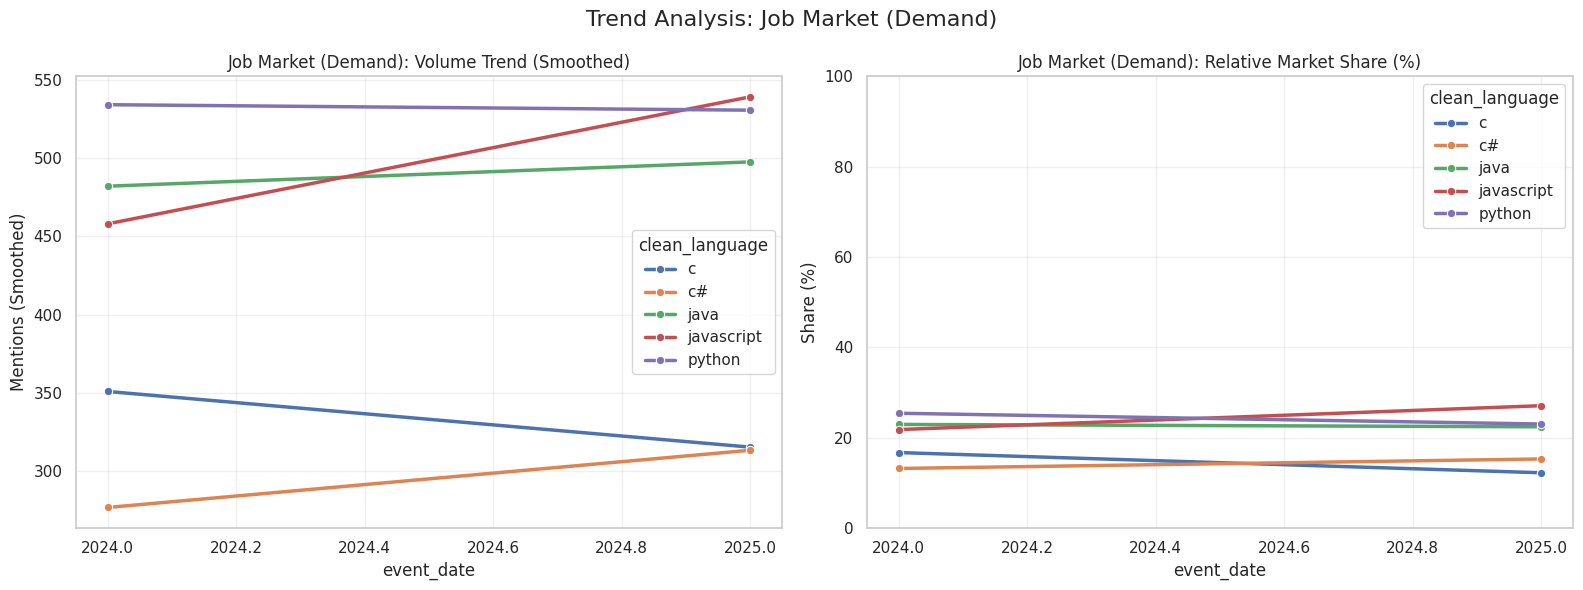

In [4]:
job_data = df_exploded[df_exploded['source_type'] == 'job']
plot_trend(job_data, "Job Market (Demand)")

## 3. Trend: StackOverflow (Supply/Interest)
Analysis of developer questions and discussions.

Top 5 languages in StackOverflow (Interest): ['python', 'r', 'c', 'java', 'c++']


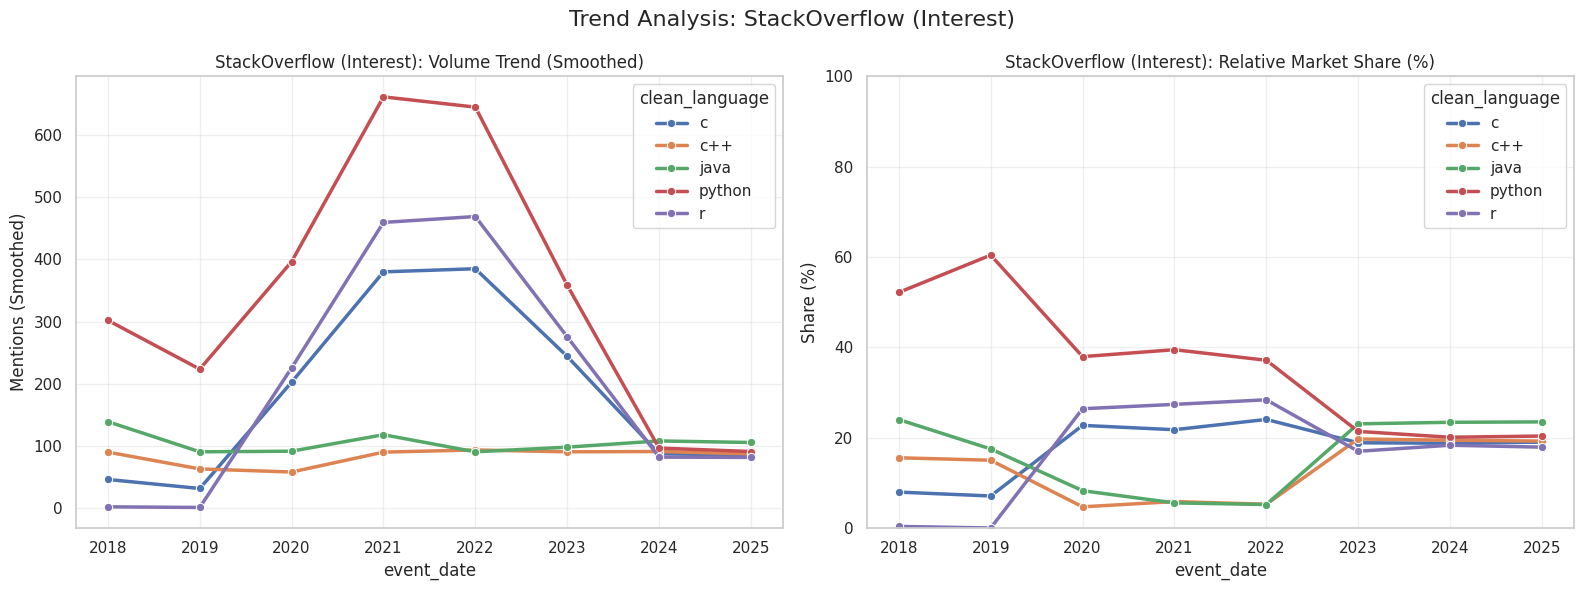

In [5]:
so_data = df_exploded[df_exploded['source_type'] == 'stackoverflow']
plot_trend(so_data, "StackOverflow (Interest)")

## 4. Trend: GitHub (Supply/Usage)
Analysis of open source repositories and activity.

Top 5 languages in GitHub (Usage): ['typescript', 'rust', 'python', 'go', 'c#']


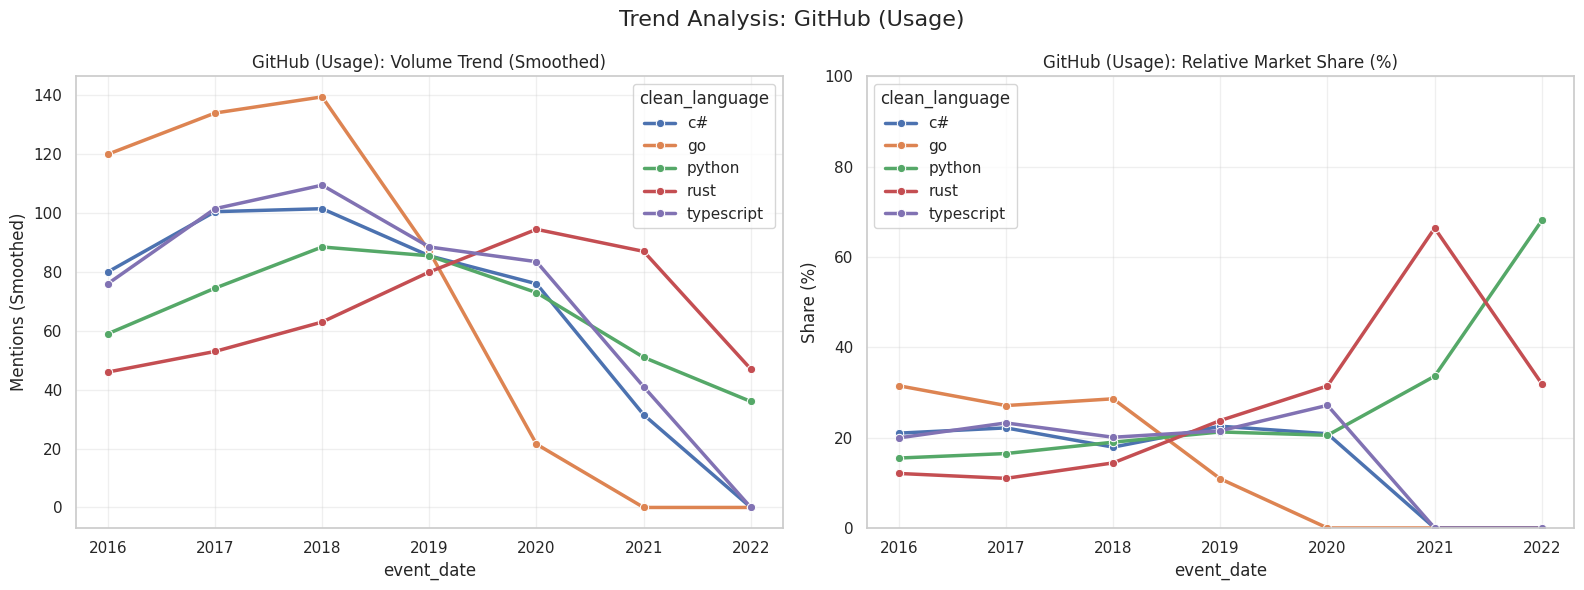

In [6]:
github_data = df_exploded[df_exploded['source_type'] == 'github']
plot_trend(github_data, "GitHub (Usage)")

## 5. Trend: All Sources Combined
Overall aggregate view of the technology landscape.

Top 5 languages in All Sources Combined: ['python', 'java', 'c', 'javascript', 'c#']


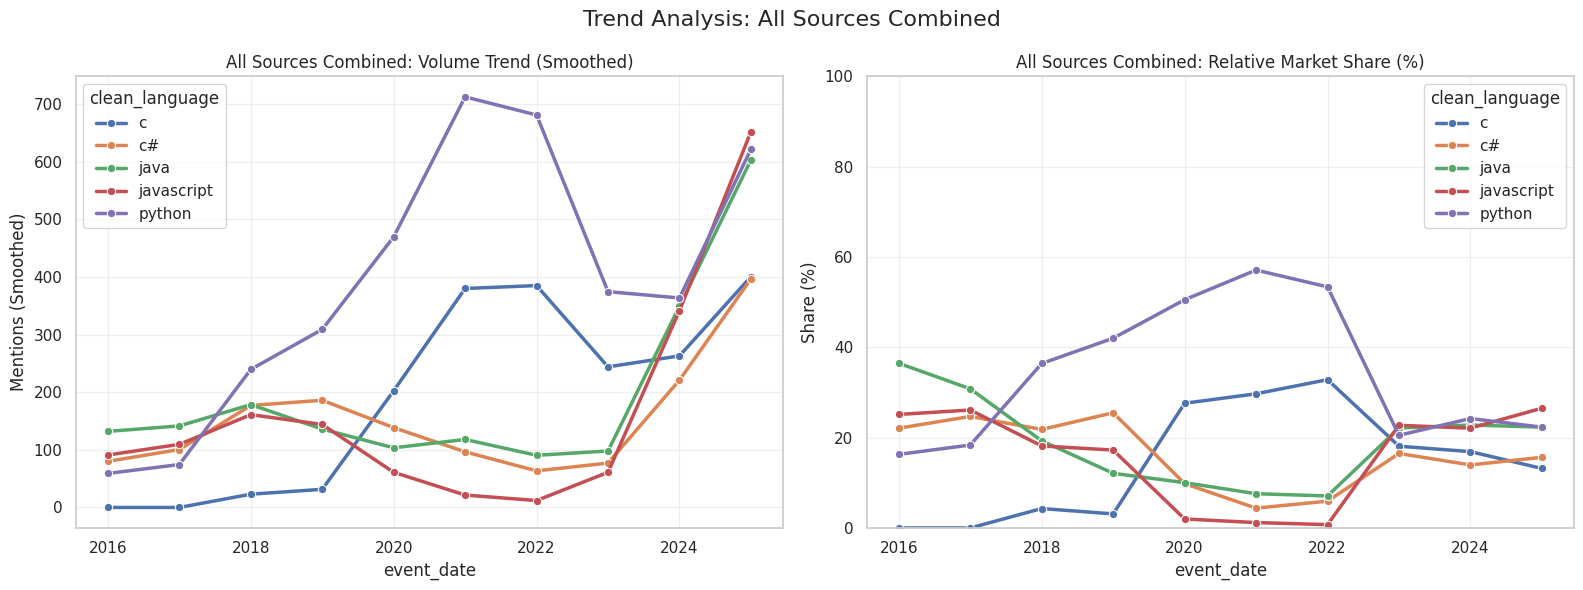

In [7]:
plot_trend(df_exploded, "All Sources Combined")